In [1]:
#Importing the needed and relevant libraries
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from keras.utils import to_categorical
from keras import layers, models
from keras_tuner import RandomSearch
from keras.optimizers import Adam, RMSprop, SGD

In [2]:
# Loading the dataset
import pandas as pd

data = pd.read_csv('hospital_readmissions.csv')

# Display the first few rows
data.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [3]:
data_info = data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [4]:
summary_stats = data.describe()

In [5]:
missing_values = data.isnull().sum()


In [6]:
# Checking the distribution of the target variable ('readmitted')

readmitted_distribution = data['readmitted'].value_counts()


In [7]:
data_info, summary_stats, missing_values, readmitted_distribution

(None,
        time_in_hospital  n_lab_procedures  n_procedures  n_medications  \
 count       25000.00000       25000.00000  25000.000000   25000.000000   
 mean            4.45332          43.24076      1.352360      16.252400   
 std             3.00147          19.81862      1.715179       8.060532   
 min             1.00000           1.00000      0.000000       1.000000   
 25%             2.00000          31.00000      0.000000      11.000000   
 50%             4.00000          44.00000      1.000000      15.000000   
 75%             6.00000          57.00000      2.000000      20.000000   
 max            14.00000         113.00000      6.000000      79.000000   
 
        n_outpatient   n_inpatient   n_emergency  
 count  25000.000000  25000.000000  25000.000000  
 mean       0.366400      0.615960      0.186600  
 std        1.195478      1.177951      0.885873  
 min        0.000000      0.000000      0.000000  
 25%        0.000000      0.000000      0.000000  
 50%      

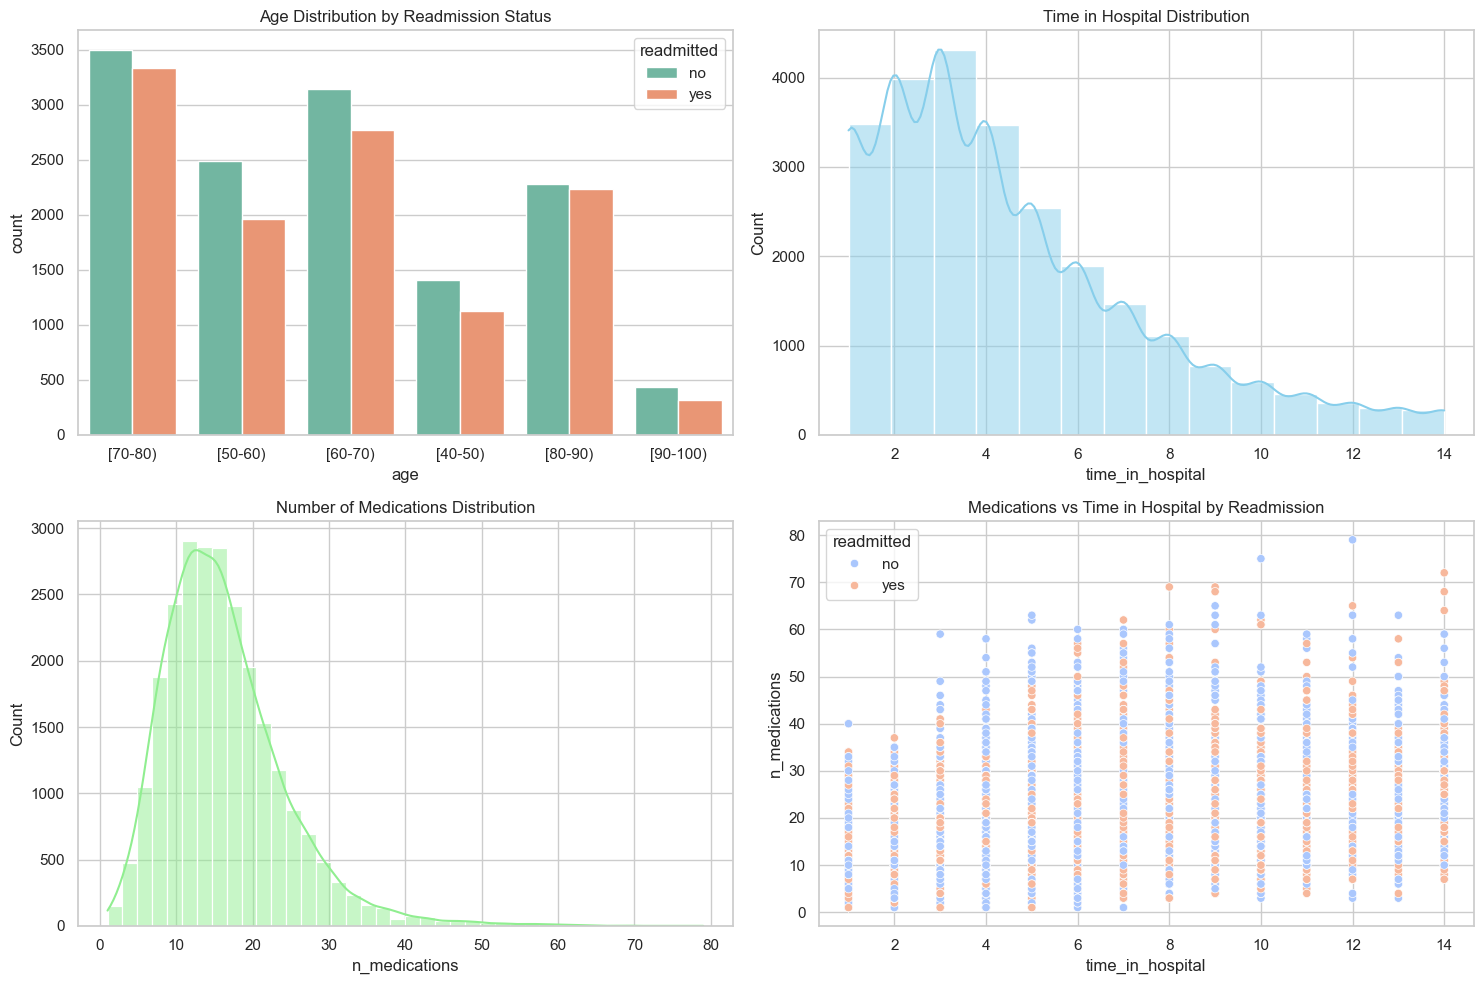

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of 'age' (which is categorical)
sns.countplot(data=data, x='age', hue='readmitted', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution by Readmission Status')

# Distribution of 'time_in_hospital'
sns.histplot(data['time_in_hospital'], kde=True, bins=14, color='skyblue', ax=axes[0, 1])
axes[0, 1].set_title('Time in Hospital Distribution')

# Distribution of 'n_medications'
sns.histplot(data['n_medications'], kde=True, bins=40, color='lightgreen', ax=axes[1, 0])
axes[1, 0].set_title('Number of Medications Distribution')

# Relationship between 'n_medications' and 'time_in_hospital'
sns.scatterplot(data=data, x='time_in_hospital', y='n_medications', hue='readmitted', palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Medications vs Time in Hospital by Readmission')

plt.tight_layout()
plt.show()


In [9]:
# Handling missing values
data.replace('Missing', pd.NA, inplace=True)

In [10]:
# Encoding categorical variables: Using Label Encoding for binary and ordinal variables, and One-Hot Encoding for nominal variables
# Encoding 'readmitted' as a binary label
label_encoder = LabelEncoder()
data['readmitted'] = label_encoder.fit_transform(data['readmitted'])

In [11]:
# Encoding 'age' as an ordinal variable
data['age'] = label_encoder.fit_transform(data['age'])

In [12]:
# Encoding binary categorical columns like 'glucose_test', 'A1Ctest', 'change', 'diabetes_med'
binary_columns = ['glucose_test', 'A1Ctest', 'change', 'diabetes_med']
for col in binary_columns:
    data[col] = label_encoder.fit_transform(data[col])


In [13]:
# Using one hot encoding For 'medical_specialty', 'diag_1', 'diag_2', 'diag_3'
data = pd.get_dummies(data, columns=['medical_specialty', 'diag_1', 'diag_2', 'diag_3'], drop_first=True)

In [14]:
# Feature Engineering (Done BEFORE scaling to ensure meaningful ratios)
data['medications_per_day'] = data['n_medications'] / (data['time_in_hospital'] + 1)
data['lab_tests_per_day'] = data['n_lab_procedures'] / (data['time_in_hospital'] + 1)
data['healthcare_utilization'] = data['n_outpatient'] + data['n_inpatient'] + data['n_emergency']
data['stay_to_medication_ratio'] = data['time_in_hospital'] / (data['n_medications'] + 1)


In [15]:
# Normalizing numerical columns (including the new engineered features)
scaler = StandardScaler()
# Selecting relevant numerical columns for scaling
numerical_columns = ['time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 
                     'n_outpatient', 'n_inpatient', 'n_emergency', 'medications_per_day', 
                     'lab_tests_per_day', 'healthcare_utilization', 'stay_to_medication_ratio']
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

In [16]:
# Displaying the processed data for verification
data.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,glucose_test,A1Ctest,...,diag_3_Diabetes,diag_3_Digestive,diag_3_Injury,diag_3_Musculoskeletal,diag_3_Other,diag_3_Respiratory,medications_per_day,lab_tests_per_day,healthcare_utilization,stay_to_medication_ratio
0,3,1.181671,1.451151,-0.205440,0.216814,1.366510,-0.522918,-0.210644,1,1,...,False,False,False,False,True,False,-0.766034,-0.270944,0.386380,0.683845
1,3,-0.484212,-0.466276,0.377601,-0.403505,-0.306494,-0.522918,-0.210644,1,1,...,False,False,False,False,True,False,-0.137228,-0.189378,-0.543491,-0.326292
2,1,0.182141,0.088769,-0.788481,0.216814,-0.306494,-0.522918,-0.210644,1,1,...,False,False,False,False,False,False,-0.262990,-0.352509,-0.543491,-0.087532
3,3,-0.817389,-0.365359,-0.788481,-0.527569,0.530008,-0.522918,-0.210644,1,1,...,True,False,False,False,False,False,0.240055,0.381582,-0.078556,-0.621562
4,2,-1.150566,-0.062607,-0.788481,-1.147888,-0.306494,-0.522918,-0.210644,1,1,...,False,False,False,False,False,True,-0.011467,1.849765,-0.543491,-0.762487


In [17]:
# Defining features (X) and target variable (y)
X = data.drop(columns=['readmitted']).astype(float)  # Features converted to float
y = data['readmitted']  # Target (readmitted yes/no)


In [18]:
print("Final shape of X:", X.shape)

Final shape of X: (25000, 39)


In [19]:
from sklearn.model_selection import StratifiedKFold

In [20]:
# Here, I am going to define the model-building function for KerasTuner
def build_model(hp):
    model = models.Sequential()
    model.add(layers.InputLayer(input_shape=(X.shape[1],)))
    
    # Add hidden layers
    for i in range(hp.Int('num_layers', 1, 5)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=64, max_value=256, step=32),
            activation=hp.Choice('activation', ['relu', 'tanh'])
        ))
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)))
    
    # Output layer
    model.add(layers.Dense(1, activation='sigmoid'))
    
    # Compile model
    model.compile(
        optimizer=hp.Choice('optimizer', ['adam', 'rmsprop', 'sgd']),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [21]:
# Initializing the RandomSearch tuner
class CVTuner(RandomSearch):
    def run_trial(self, trial, x, y, *fit_args, **fit_kwargs):
        # 3-fold Stratified CV for faster runtime
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        val_scores = []

        for train_idx, val_idx in skf.split(x, y):
            X_train_fold, X_val_fold = x[train_idx], x[val_idx]
            y_train_fold, y_val_fold = y[train_idx], y[val_idx]

            model = self.hypermodel.build(trial.hyperparameters)
            history = model.fit(
                X_train_fold, y_train_fold,
                validation_data=(X_val_fold, y_val_fold),
                epochs=10,
                batch_size=32,
                verbose=0
            )
            fold_val_acc = max(history.history['val_accuracy'])
            val_scores.append(fold_val_acc)

        mean_val_acc = np.mean(val_scores)
        self.oracle.update_trial(trial.trial_id, {'val_accuracy': mean_val_acc})
        # self.save_model is bypassed to prevent PyTorch-backend NotImplementedError

# Creating the tuner instance using CVTuner (max_trials=5 for speed)
tuner = CVTuner(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuning_results',
    project_name='hospital_readmissions_tuning'
)

C:\Python314\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [22]:
# Running the search on the entire dataset (epochs=10 for fast search)
X_np = X.values if hasattr(X, 'values') else X
y_np = y.values if hasattr(y, 'values') else y

tuner.search(X_np, y_np, epochs=10)

Trial 5 Complete [00h 02m 29s]
val_accuracy: 0.6188001831372579

Best val_accuracy So Far: 0.6229199965794882
Total elapsed time: 00h 12m 00s


In [23]:
# Getting the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters:")
print(f"Number of layers: {best_hps.get('num_layers')}")
for i in range(best_hps.get('num_layers')):
    print(f"Layer {i} units: {best_hps.get(f'units_{i}')}, dropout: {best_hps.get(f'dropout_{i}')}")
print(f"Activation function: {best_hps.get('activation')}")
print(f"Optimizer: {best_hps.get('optimizer')}")

Best Hyperparameters:
Number of layers: 2
Layer 0 units: 64, dropout: 0.30000000000000004
Layer 1 units: 64, dropout: 0.1
Activation function: relu
Optimizer: rmsprop


In [24]:
# Creating a training/testing split
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Building the final model with the best hyperparameters
def build_final_model(best_hps):
    model = models.Sequential()
    model.add(layers.InputLayer(input_shape=(X_train_final.shape[1],)))

    num_layers = best_hps.get('num_layers')
    activation = best_hps.get('activation')
    optimizer_choice = best_hps.get('optimizer')

    for i in range(num_layers):
        units = best_hps.get(f'units_{i}')
        dropout_rate = best_hps.get(f'dropout_{i}')
        model.add(layers.Dense(units=units, activation=activation))
        model.add(layers.Dropout(rate=dropout_rate))

    model.add(layers.Dense(1, activation='sigmoid'))

    # Choose optimizer
    if optimizer_choice == 'adam':
        optimizer = Adam()
    elif optimizer_choice == 'rmsprop':
        optimizer = RMSprop()
    else:
        optimizer = SGD()

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

final_model = build_final_model(best_hps)

In [26]:
# Training the best model
history = final_model.fit(X_train_final, y_train_final, epochs=50, batch_size=32, validation_data=(X_test_final, y_test_final))

Epoch 1/50


  1/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5938 - loss: 0.6712

 12/625 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5278 - loss: 0.7000

 19/625 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.5267 - loss: 0.6987

 31/625 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5294 - loss: 0.6970 

...

595/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6456 - loss: 0.6311

605/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6456 - loss: 0.6312

615/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6455 - loss: 0.6312

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6455 - loss: 0.6313

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6441 - loss: 0.6349 - val_accuracy: 0.6174 - val_loss: 0.6567


In [27]:
# Now, I am evaluating the model on the test set
test_loss, test_accuracy = final_model.evaluate(X_test_final, y_test_final, verbose=0)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


Test Loss: 0.6567279100418091
Test Accuracy: 0.6173999905586243


In [28]:
# Generate predictions
y_pred_probs = final_model.predict(X_test_final)  # Predicted probabilities
y_pred = (y_pred_probs > 0.5).astype(int) # Convert probabilities to binary labels


  1/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 17/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 39/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 62/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 84/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

107/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

132/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


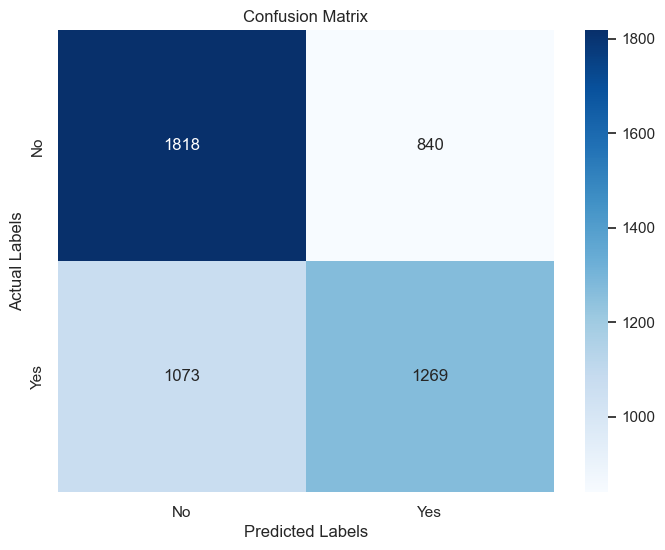

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test_final, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()

In [30]:
# Calculate metrics
accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred)
recall = recall_score(y_test_final, y_pred)
f1 = f1_score(y_test_final, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.6174
Precision: 0.6017069701280228
Recall: 0.5418445772843723
F1 Score: 0.570208941810829


In [31]:
# Classification report
print("Classification Report:")
print(classification_report(y_test_final, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.68      0.66      2658
           1       0.60      0.54      0.57      2342

    accuracy                           0.62      5000
   macro avg       0.62      0.61      0.61      5000
weighted avg       0.62      0.62      0.62      5000



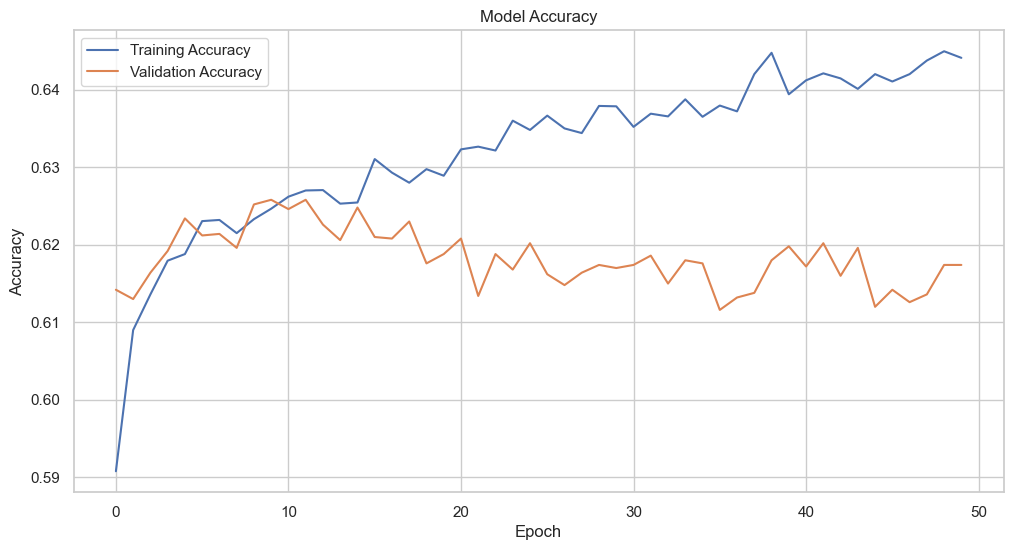

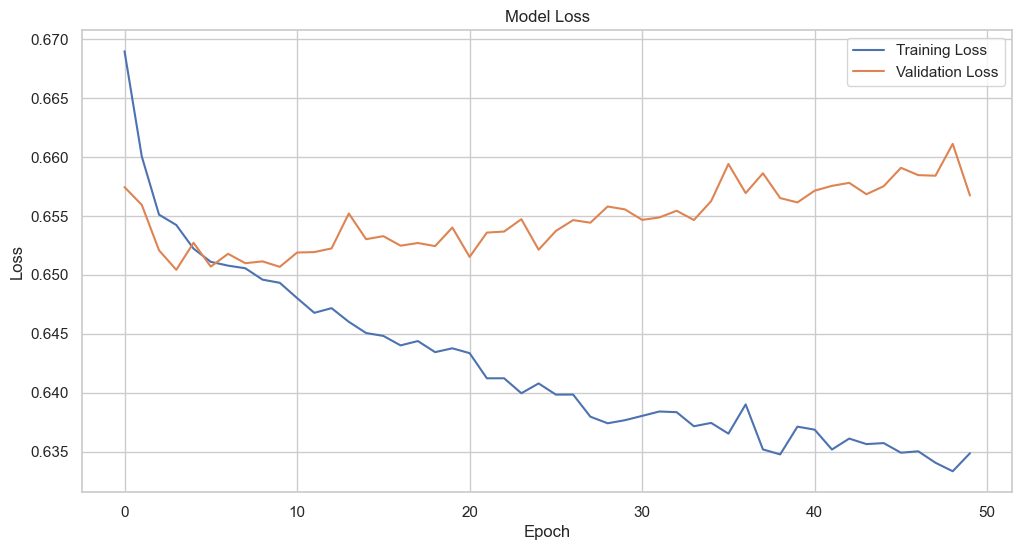

In [32]:
# Plot accuracy
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [33]:
# Calculating the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_final, y_pred_probs)
roc_auc = auc(fpr, tpr)
print(f"Test AUC: {roc_auc}")

Test AUC: 0.6547971770765664


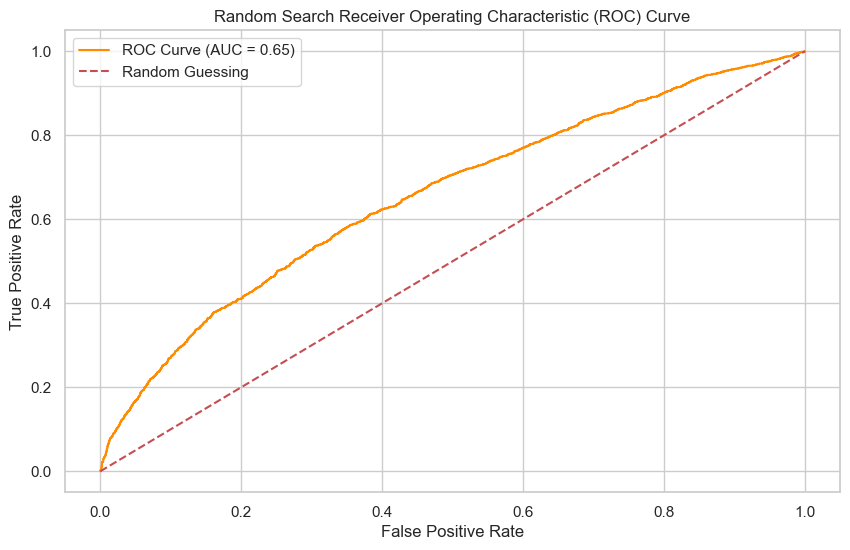

In [34]:
# Plotting the ROC Curve
plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guessing')
plt.title('Random Search Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
# Trainning a Random Forest model on the final training set
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_final, y_train_final)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
# Evaluating the Random Forest on the final test set
rf_predictions = rf_model.predict(X_test_final)
print("Random Forest Classification Report:")
print(classification_report(y_test_final, rf_predictions))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.68      0.64      2658
           1       0.58      0.51      0.55      2342

    accuracy                           0.60      5000
   macro avg       0.60      0.59      0.59      5000
weighted avg       0.60      0.60      0.60      5000



In [38]:
from xgboost import XGBClassifier

In [39]:
# Trainning an XGBoost model on the final training set
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_final, y_train_final)

C:\Users\amanl\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:200: UserWarning: [00:57:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [40]:
# Evaluating the XGBoost model on the final test set
xgb_predictions = xgb_model.predict(X_test_final)
print("XGBoost Classification Report:")
print(classification_report(y_test_final, xgb_predictions))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.66      0.63      2658
           1       0.58      0.52      0.55      2342

    accuracy                           0.60      5000
   macro avg       0.59      0.59      0.59      5000
weighted avg       0.59      0.60      0.59      5000



In [41]:
# Add Logistic Regression baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Training a Logistic Regression baseline model with L2 regularization
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_final, y_train_final)

# Evaluating the Logistic Regression on the test set
lr_predictions = lr_model.predict(X_test_final)
print("Logistic Regression Classification Report:")
print(classification_report(y_test_final, lr_predictions))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.79      0.68      2658
           1       0.63      0.41      0.50      2342

    accuracy                           0.61      5000
   macro avg       0.62      0.60      0.59      5000
weighted avg       0.61      0.61      0.59      5000

